In [1]:
import pdb
import copy
import numpy as np
import matplotlib.cm as cm
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
import matplotlib
from sklearn.metrics import silhouette_samples, silhouette_score
import nibabel as nib
from nilearn import plotting
from nilearn import image
from nilearn import datasets, surface
import matplotlib.colors as mcolors
import numpy as np
import os
import matplotlib.font_manager
plt.rcParams.update({'font.size': 16})


/home/rk1593/.conda/envs/wedding_schema/lib/python3.8/site-packages/nilearn/datasets/__init__.py:93: FutureWarning: Fetchers from the nilearn.datasets module will be updated in version 0.9 to return python strings instead of bytes and Pandas dataframes instead of Numpy arrays.
  warn("Fetchers from the nilearn.datasets module will be "


In [2]:
from adjustText import adjust_text


# Colored Brain

In [3]:

def get_cluster_id_to_distilled_searchlights(K, distill_numLights,
                      exaggerated_0, weight_it, cap_zero, fraction, threshold, by_sil):
    cluster_id_to_distilled_lights = {}
    for cluster_id in range(1,K+1):
        ranks_dir = "/scratch/gpfs/rk1593/clustering_output/kmeans_searchlight_ranks/K" + str(K) + "/kmeans" + str(K) + "cluster" + str(cluster_id) + "_ranks"
        if by_sil:
            ranks_dir += "_by_silhouttes"
        else:
            if exaggerated_0:
                ranks_dir += ("_Consider0_T" + str(threshold)) 
            else:
                ranks_dir += "_NoConsider0"
            if weight_it:
                ranks_dir += ("_WeightByMean")
            else:
                ranks_dir += "_NoWeightByMean"
            if cap_zero:
                ranks_dir += "_CapZero"
            else:
                ranks_dir += "_NoCapZero"
        ranks_dir += ".csv"
        print(ranks_dir)
        ranks_df = pd.read_csv(ranks_dir)
        ranked_searchlights_in_cluster = ranks_df["searchlights_in_cluster"].tolist()
        if fraction:
            cluster_id_to_distilled_lights[cluster_id] = ranked_searchlights_in_cluster[0:int(distill_numLights*len(ranked_searchlights_in_cluster))]
        else: 
            cluster_id_to_distilled_lights[cluster_id] = ranked_searchlights_in_cluster[0:distill_numLights]

    return cluster_id_to_distilled_lights

def plot_colored_brain(K,cluster_assignment_csv_path, brain_image_path, optional_focus = None,
                               colored_brain_np = [], distill_it = False, distill_numLights = 1000,by_sil = True,
                      exaggerated_0 = False, weight_it = True,
                       cap_zero = False, fraction = False, threshold = None, title = "", cmap = "gist_ncar_r"):
    """
    This function plots a colored brain based on the cluster assignment of kmodes

    cluster_assignment_csv_path: data frame with columns: "cluster_assignment", "searchlight", "features"

    brain_image_path: shape (97, 115, 97) image which will be used to get the affine and header

    output_path: where these plots will end up saved
    """
    # get the brain_image_path
    matplotlib.rcParams['font.family'] = "sans-serif"
    matplotlib.rcParams['font.sans-serif'] =  "Arial"
    img = nib.load(brain_image_path)
    if distill_it:
        cluster_id_to_distilled_lights = get_cluster_id_to_distilled_searchlights(K, distill_numLights, exaggerated_0, weight_it, cap_zero, fraction, threshold, by_sil)
    # get colored_brain_np if it is not fed in
    if len(colored_brain_np) == 0:
        # get the cluster assignment
        df = pd.read_csv(cluster_assignment_csv_path)
        colored_brain_np = np.ones(shape=(97, 115, 97))
        # colored_brain_np = colored_brain_np.astype(float)
        # populate the brain_np with the cluster assignment
        for index,row in df.iterrows():
            light_id_splitted = row["searchlight"].split("_")
            light_id_str = row["searchlight"]
            cluster_id = int(row["cluster_assignment"])
            if distill_it and light_id_str not in cluster_id_to_distilled_lights[cluster_id]:
                continue
            x = int(light_id_splitted[0])
            y = int(light_id_splitted[1])
            z = int(light_id_splitted[2])
            colored_brain_np[x,y,z] = int(row["cluster_assignment"])
    original_colored_brain_np = copy.copy(colored_brain_np)
    if optional_focus != None:
        colored_brain_np[colored_brain_np != optional_focus] = 0
    # turn into nifti and plot with nilearn
    colored_brain = nib.Nifti1Image(colored_brain_np, affine=img.affine, header = img.header, extra = img.extra)
    print("optional_focus: ", optional_focus)
    print("len(np.unique(colored_brain_np)): ", len(np.unique(colored_brain_np)))
    print(np.unique(colored_brain_np)) # cmap = cm.get_cmap('Spectral', 20),
    display = plotting.plot_roi(colored_brain, draw_cross = False, cut_coords = (-4,-30,20), colorbar = True, title =  title, cmap = cmap)#"K = " + str(K) + " & Focus Cluster = " + str(optional_focus) )
    #plotting.plot_surf_roi(roi_map = colored_brain)
    plt.savefig(f"maps/{K}_plot_roi_optionalSelect{optional_focus}.pdf", format = "pdf")
    plt.show()#savefig("map.pdf", format = "pdf")
    display.close()
    # Load a standard surface (fsaverage)
    fsaverage = datasets.fetch_surf_fsaverage()
    # Project the 3D ROI onto the surface (left hemisphere for example)
    if optional_focus == None:
        roi_texture = surface.vol_to_surf(colored_brain, fsaverage.pial_left, interpolation = "nearest_most_frequent")
        # Plot the surface ROI
        plotting.plot_surf_roi(
            fsaverage.infl_left,        # Inflated surface mesh
            roi_map=roi_texture,        # Surface ROI (projected values)
            hemi='left',
            title='Surface ROI',
            colorbar=True,
            threshold=0.5,
            cmap = cmap
        )
        plt.savefig(f"maps/{K}_plot_surfROI_left.pdf", format = "pdf")
        plt.show()
        roi_texture = surface.vol_to_surf(colored_brain, fsaverage.pial_right)
        # Plot the surface ROI
      
        plotting.plot_surf_roi(
            fsaverage.infl_right,        # Inflated surface mesh
            roi_map=roi_texture,        # Surface ROI (projected values)
            hemi='right',
            title='Surface ROI',
            colorbar=True,
            threshold=0.5 ,
            cmap = cmap,
        )
        plt.savefig(f"maps/{K}_plot_surfROI_right.pdf", format = "pdf")
        plt.show()
        roi_texture = surface.vol_to_surf(colored_brain, fsaverage.pial_right)

    return original_colored_brain_np
    

<ipython-input-7-c936e9659354>:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  orig_cmap = cm.get_cmap('gist_ncar', 256)


optional_focus:  None
len(np.unique(colored_brain_np)):  6
[1. 2. 3. 4. 5. 6.]


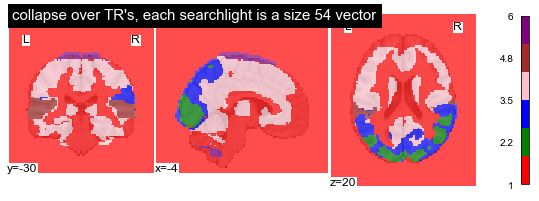

ValueError: "interpolation" should be one of ('linear', 'nearest')

In [7]:
from matplotlib.colors import LinearSegmentedColormap

# Load the original colormap
orig_cmap = cm.get_cmap('gist_ncar', 256)

# Slice to remove the top part (where white occurs)
# Keep only the first ~90% to eliminate the white tip
new_colors = orig_cmap(np.linspace(0, 0.85, 256))

# Create a new colormap
cmap = mcolors.ListedColormap(['red', 'green', 'blue', 'yellow', "pink", "brown", "purple"])


for K in range(6,7):
    
    colored_brain_np = plot_colored_brain(K = K,
                    cluster_assignment_csv_path = "/scratch/gpfs/KNORMAN/rkempner/clustering_output/kmeans_assignments_just_means/kmeans_" + str(K) +  "clusters_just_means.csv", #"/scratch/gpfs/rk1593/clustering_output/kmeans_assignments_tval/kmeans_" + str(K) +  "clusters_tval.csv",
                           brain_image_path = "/home/rk1593/wedding_schema/code/python/kmeans/rentireAAL_wfupickatlas.nii", 
                            by_sil = False,
                            exaggerated_0 = False, weight_it = True, cap_zero = False,
                            distill_it = False,
                            distill_numLights = 0.5,
                            fraction = True,
                            threshold = 0.5,
                            optional_focus = None,
                           colored_brain_np = [],#colored_brain_np6       ,       
                            title= "collapse over TR's, each searchlight is a size 54 vector",
                                          cmap = cmap
                            )
    
    
    # for optional_focus in range(1,K +1):
        
    #     colored_brain_np6 = plot_colored_brain(K = K,
    #                     cluster_assignment_csv_path = "/scratch/gpfs/rk1593/clustering_output/kmeans_assignments_tval_collapseTR/kmeans_" + str(K) +  "clusters_collapseTR.csv", #"/scratch/gpfs/rk1593/clustering_output/kmeans_assignments_tval/kmeans_" + str(K) +  "clusters_tval.csv",
    #                            brain_image_path = "/home/rk1593/wedding_schema/code/python/kmeans/rentireAAL_wfupickatlas.nii", 
    #                             by_sil = False,
    #                             exaggerated_0 = False, weight_it = True, cap_zero = False,
    #                             distill_it = False,
    #                             distill_numLights = 0.5,
    #                             fraction = True,
    #                             threshold = 0.5,
    #                             optional_focus = optional_focus,
    #                            colored_brain_np = [],#colored_brain_np    ,       
    #                             title= "collapse over TR's, each searchlight is a size 54 vector",
    #                             cmap = cmap
    #                             )






optional_focus:  None
len(np.unique(colored_brain_np)):  6
[1. 2. 3. 4. 5. 6.]


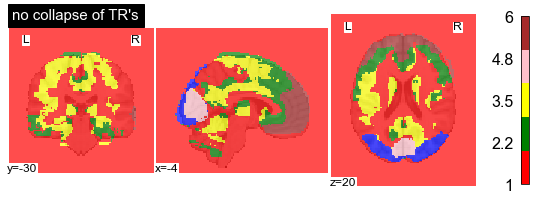

ValueError: "interpolation" should be one of ('linear', 'nearest')

In [15]:
K = 6
cmap = mcolors.ListedColormap(['red', 'green', 'blue', 'yellow', "pink", "brown"])

colored_brain_np6 = plot_colored_brain(K = K,
                cluster_assignment_csv_path = "/scratch/gpfs/rk1593/clustering_output/kmeans_assignments_tval/kmeans_" + str(K) +  "clusters_tval.csv",
                       brain_image_path = "/home/rk1593/wedding_schema/code/python/kmeans/rentireAAL_wfupickatlas.nii", 
                        by_sil = False,
                        exaggerated_0 = False, weight_it = True, cap_zero = False,
                        distill_it = False,
                        distill_numLights = 0.5,
                        fraction = True,
                        threshold = 0.5,
                        optional_focus = None,
                       colored_brain_np = [],
                                       cmap = cmap,
                                       title = "no collapse of TR's"#colored_brain_np6              
                        )


